## Figure 1: scatter vs. mass (or rp), for all observables
## Figure 2: correlation involving Ncyl, correlation $\times$ scatter
## Figure 3: correlation involving Ycyl, correlation $\times$ scatter
## Figure 4: Ncyl selection bias
## Figure 5: Ycyl selection bias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
twin_axes = []
bottom_images = []
rng = np.random.default_rng(42)
mass_bins = np.logspace(13, 15, 25)
y_cyl_bins = ["low", "high"]
mass_grid = np.logspace(13, 15, 200)
rp_grid = np.logspace(-1, 1, 80)
log_mass_mesh, log_rp_mesh = np.meshgrid(np.log10(mass_grid), np.log10(rp_grid))
# TODO: add real data
sigma_ln_ncyl = 0.25 * (mass_grid / mass_grid.min()) ** -0.15 + 0.05
sigma_y_cyl = 0.18 * (mass_grid / mass_grid.min()) ** -0.12 + 0.03

for i, ax in enumerate(axes.flat, start=1):
    if i <= 2:
        hist_axis = ax.twinx()
        twin_axes.append(hist_axis)
        if i == 1:
            ax.plot(mass_grid, sigma_ln_ncyl, color="black", linewidth=2.5, label=r"$\sigma_{\ln N_{\rm cyl}}$")
        else:
            ax.plot(mass_grid, sigma_y_cyl, color="black", linewidth=2.5, label=r"$\sigma_{Y_{\rm cyl}}$")
            for y_cyl_bin, log_mass_center in zip(y_cyl_bins, [13.55, 14.15]):
                # TODO: add real data
                masses = 10 ** rng.normal(log_mass_center, 0.15, size=600)
                hist_axis.hist(masses, bins=mass_bins, alpha=0.2, label=rf"$Y_{{\rm cyl}}$ {y_cyl_bin}")
        hist_axis.set_ylabel("Mass PDF")
        hist_axis.set_xscale("log")
    else:
        # TODO: add real data
        if i == 3:
            matrix = 0.25 + 0.55 * np.exp(-((log_mass_mesh - 14.1) ** 2 / 0.32 + (log_rp_mesh + 0.15) ** 2 / 0.65))
            matrix += 0.12 * np.sin(2.5 * log_mass_mesh) * np.exp(-0.5 * log_rp_mesh ** 2)
        else:
            matrix = 0.18 + 0.62 / (1 + np.exp(-4.0 * (log_mass_mesh - 14.0)))
            matrix *= 0.75 + 0.2 * np.cos(2.0 * log_rp_mesh)
        matrix = np.clip(matrix, 0, 1)
        image = ax.imshow(matrix, origin="lower", extent=[1e13, 1e15, 1e-1, 1e1], aspect="auto", vmin=0, vmax=1)
        bottom_images.append((ax, image))

    ax.set_xscale("log")
    ax.set_xlabel(r"$M_{500c}\,[h^{-1}M_\odot]$")
    ax.set_box_aspect(1)

axes.flat[0].set_ylabel(r"$\sigma_{\ln N_{\rm cyl}}$")
axes.flat[1].set_ylabel(r"$\sigma_{Y_{\rm cyl}}$")
axes.flat[2].set_ylabel(r"$r_p\,[h^{-1}{\rm Mpc}]$")
axes.flat[3].tick_params(axis="y", which="both", labelleft=False)

for ax, title in zip(axes.flat[2:], [r"$\sigma_{\ln \Sigma}$", r"$\sigma_{\ln y}$"]):
    ax.set_title(title)
    ax.set_yscale("log")

for ax, image in bottom_images:
    cb = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04, shrink=0.8)
    cb.ax.tick_params(which="major", length=9, width=1.5)

for ax in list(axes.flat) + twin_axes:
    ax.tick_params(which="major", length=9, width=1.5)

fig.subplots_adjust(wspace=0.42, hspace=0.32)
plt.show()

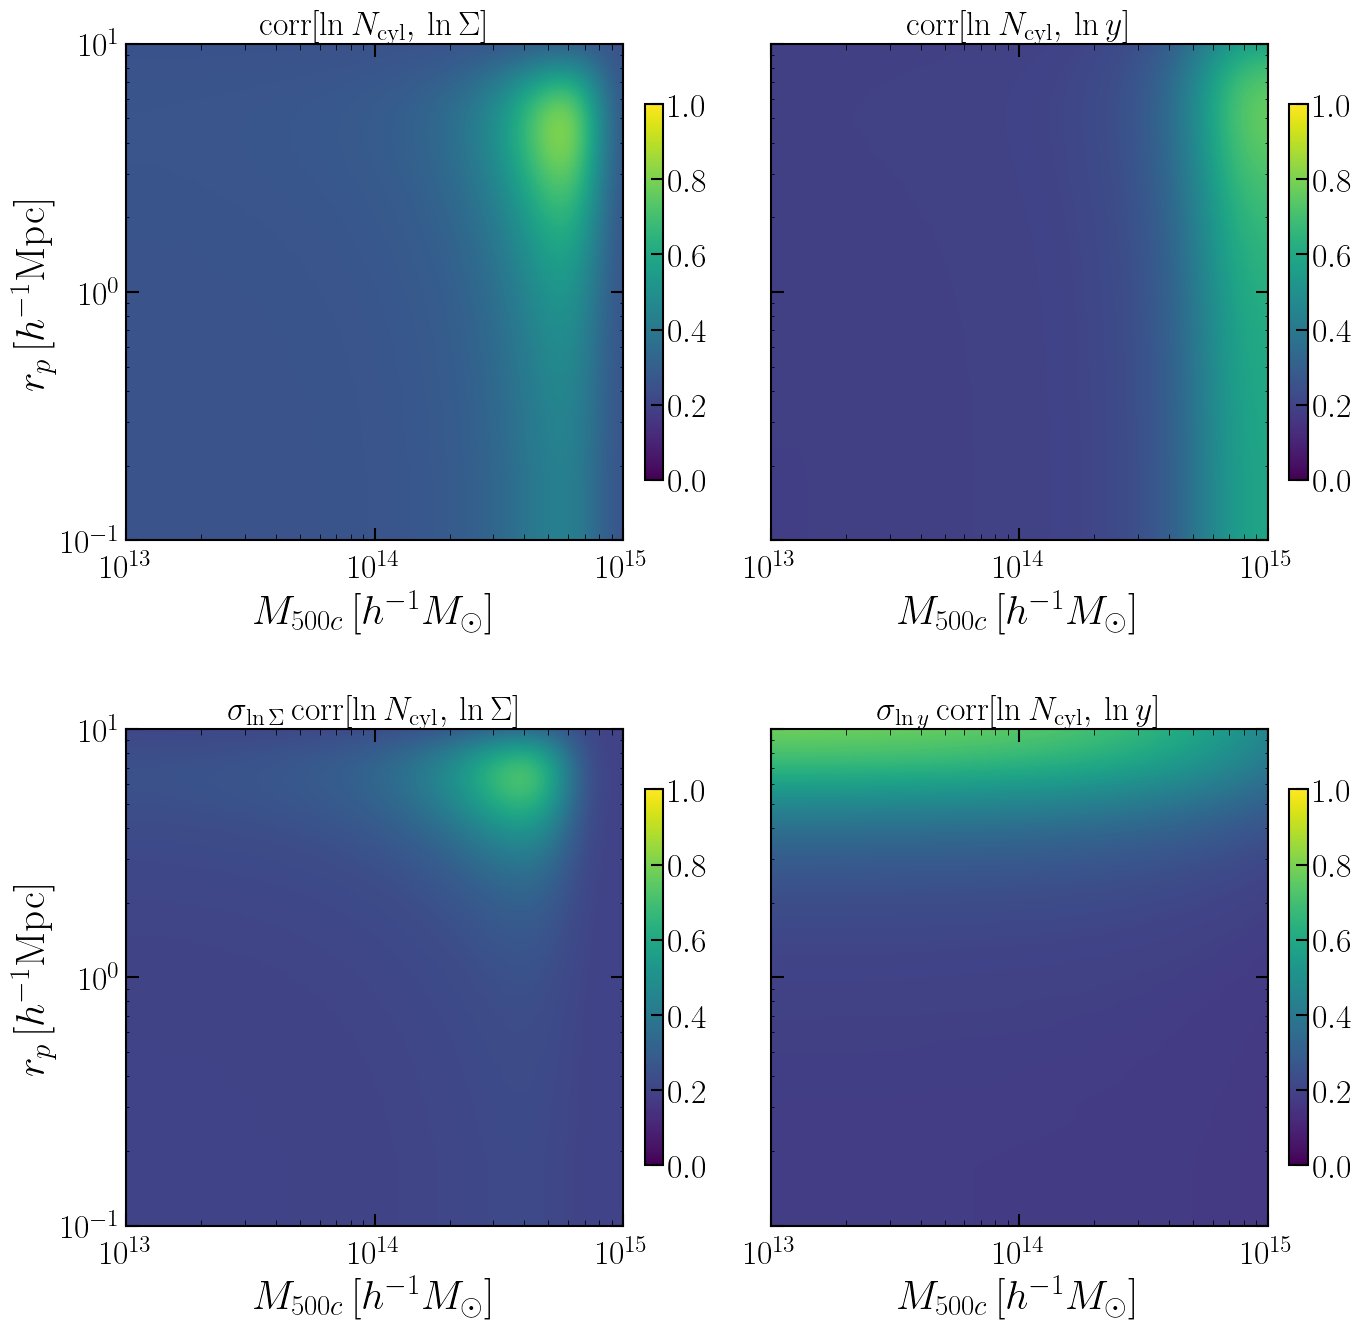

In [11]:
# TODO: add real data
matrices = [
    0.25 + 0.55 * np.exp(-((log_mass_mesh - 14.1) ** 2 / 0.32 + (log_rp_mesh + 0.15) ** 2 / 0.65)),
    0.18 + 0.62 / (1 + np.exp(-4.0 * (log_mass_mesh - 14.0))) * (0.75 + 0.2 * np.cos(2.0 * log_rp_mesh)),
    0.2 + 0.5 * np.exp(-((log_mass_mesh - 13.75) ** 2 / 0.24 + (log_rp_mesh - 0.25) ** 2 / 0.5)),
    0.15 + 0.65 * np.exp(-0.35 * (log_mass_mesh - 13.0)) * (1 / (1 + np.exp(-3.0 * log_rp_mesh))),
]

titles = [
    r"${\rm corr}[\ln N_{\rm cyl},\,\ln \Sigma]$",
    r"${\rm corr}[\ln N_{\rm cyl},\,\ln y]$",
    r"$\sigma_{\ln \Sigma}\,{\rm corr}[\ln N_{\rm cyl},\,\ln \Sigma]$",
    r"$\sigma_{\ln y}\,{\rm corr}[\ln N_{\rm cyl},\,\ln y]$",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax, matrix, title in zip(axes.flat, matrices, titles):
    matrix = np.clip(matrix, 0, 1)
    image = ax.imshow(
        matrix,
        origin="lower",
        extent=[mass_grid.min(), mass_grid.max(), rp_grid.min(), rp_grid.max()],
        aspect="auto",
        vmin=0,
        vmax=1,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$M_{500c}\,[h^{-1}M_\odot]$")
    ax.set_ylabel(r"$r_p\,[h^{-1}{\rm Mpc}]$")
    ax.set_title(title)
    ax.set_box_aspect(1)
    ax.tick_params(which="major", length=9, width=1.5)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04, shrink=0.8)
    colorbar.ax.tick_params(which="major", length=9, width=1.5)

for ax in axes[:, 1]:
    ax.set_ylabel("")
    ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(wspace=0.42, hspace=0.32)
plt.show()

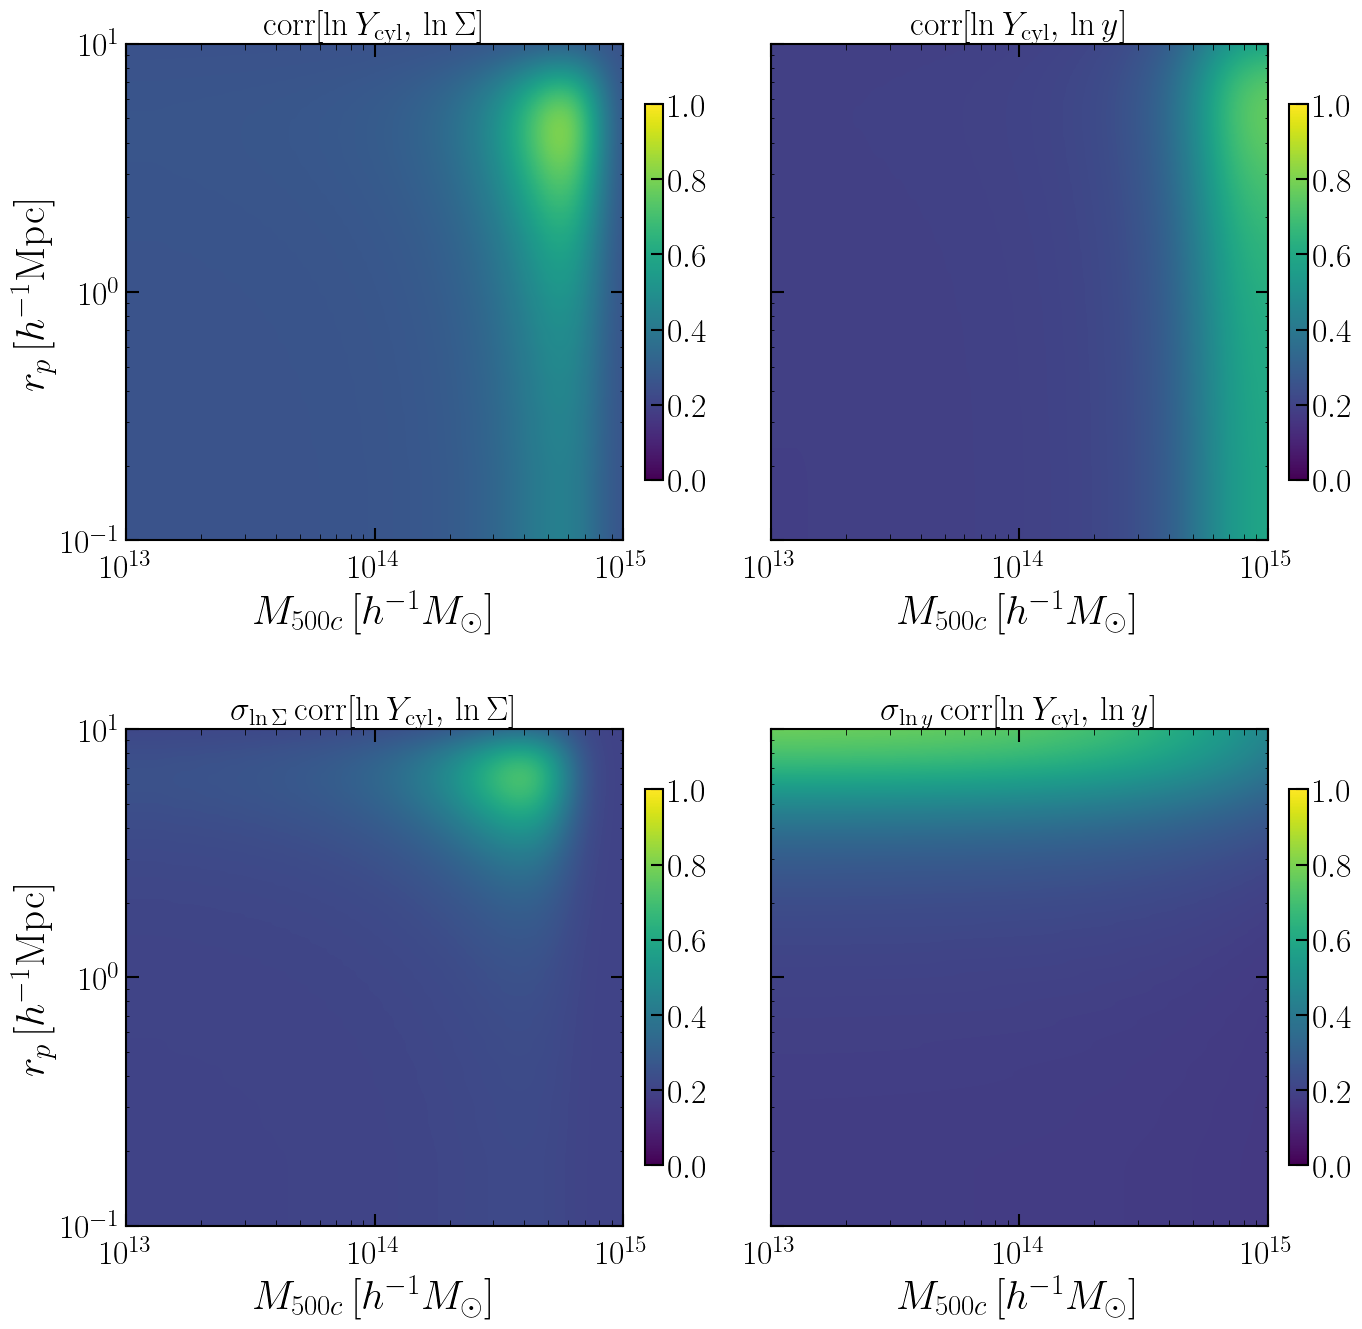

In [12]:
# TODO: add real data
matrices = [
    0.25 + 0.55 * np.exp(-((log_mass_mesh - 14.1) ** 2 / 0.32 + (log_rp_mesh + 0.15) ** 2 / 0.65)),
    0.18 + 0.62 / (1 + np.exp(-4.0 * (log_mass_mesh - 14.0))) * (0.75 + 0.2 * np.cos(2.0 * log_rp_mesh)),
    0.2 + 0.5 * np.exp(-((log_mass_mesh - 13.75) ** 2 / 0.24 + (log_rp_mesh - 0.25) ** 2 / 0.5)),
    0.15 + 0.65 * np.exp(-0.35 * (log_mass_mesh - 13.0)) * (1 / (1 + np.exp(-3.0 * log_rp_mesh))),
]

titles = [
    r"${\rm corr}[\ln Y_{\rm cyl},\,\ln \Sigma]$",
    r"${\rm corr}[\ln Y_{\rm cyl},\,\ln y]$",
    r"$\sigma_{\ln \Sigma}\,{\rm corr}[\ln Y_{\rm cyl},\,\ln \Sigma]$",
    r"$\sigma_{\ln y}\,{\rm corr}[\ln Y_{\rm cyl},\,\ln y]$",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax, matrix, title in zip(axes.flat, matrices, titles):
    matrix = np.clip(matrix, 0, 1)
    image = ax.imshow(
        matrix,
        origin="lower",
        extent=[mass_grid.min(), mass_grid.max(), rp_grid.min(), rp_grid.max()],
        aspect="auto",
        vmin=0,
        vmax=1,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$M_{500c}\,[h^{-1}M_\odot]$")
    ax.set_ylabel(r"$r_p\,[h^{-1}{\rm Mpc}]$")
    ax.set_title(title)
    ax.set_box_aspect(1)
    ax.tick_params(which="major", length=9, width=1.5)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04, shrink=0.8)
    colorbar.ax.tick_params(which="major", length=9, width=1.5)

for ax in axes[:, 1]:
    ax.set_ylabel("")
    ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(wspace=0.42, hspace=0.32)
plt.show()

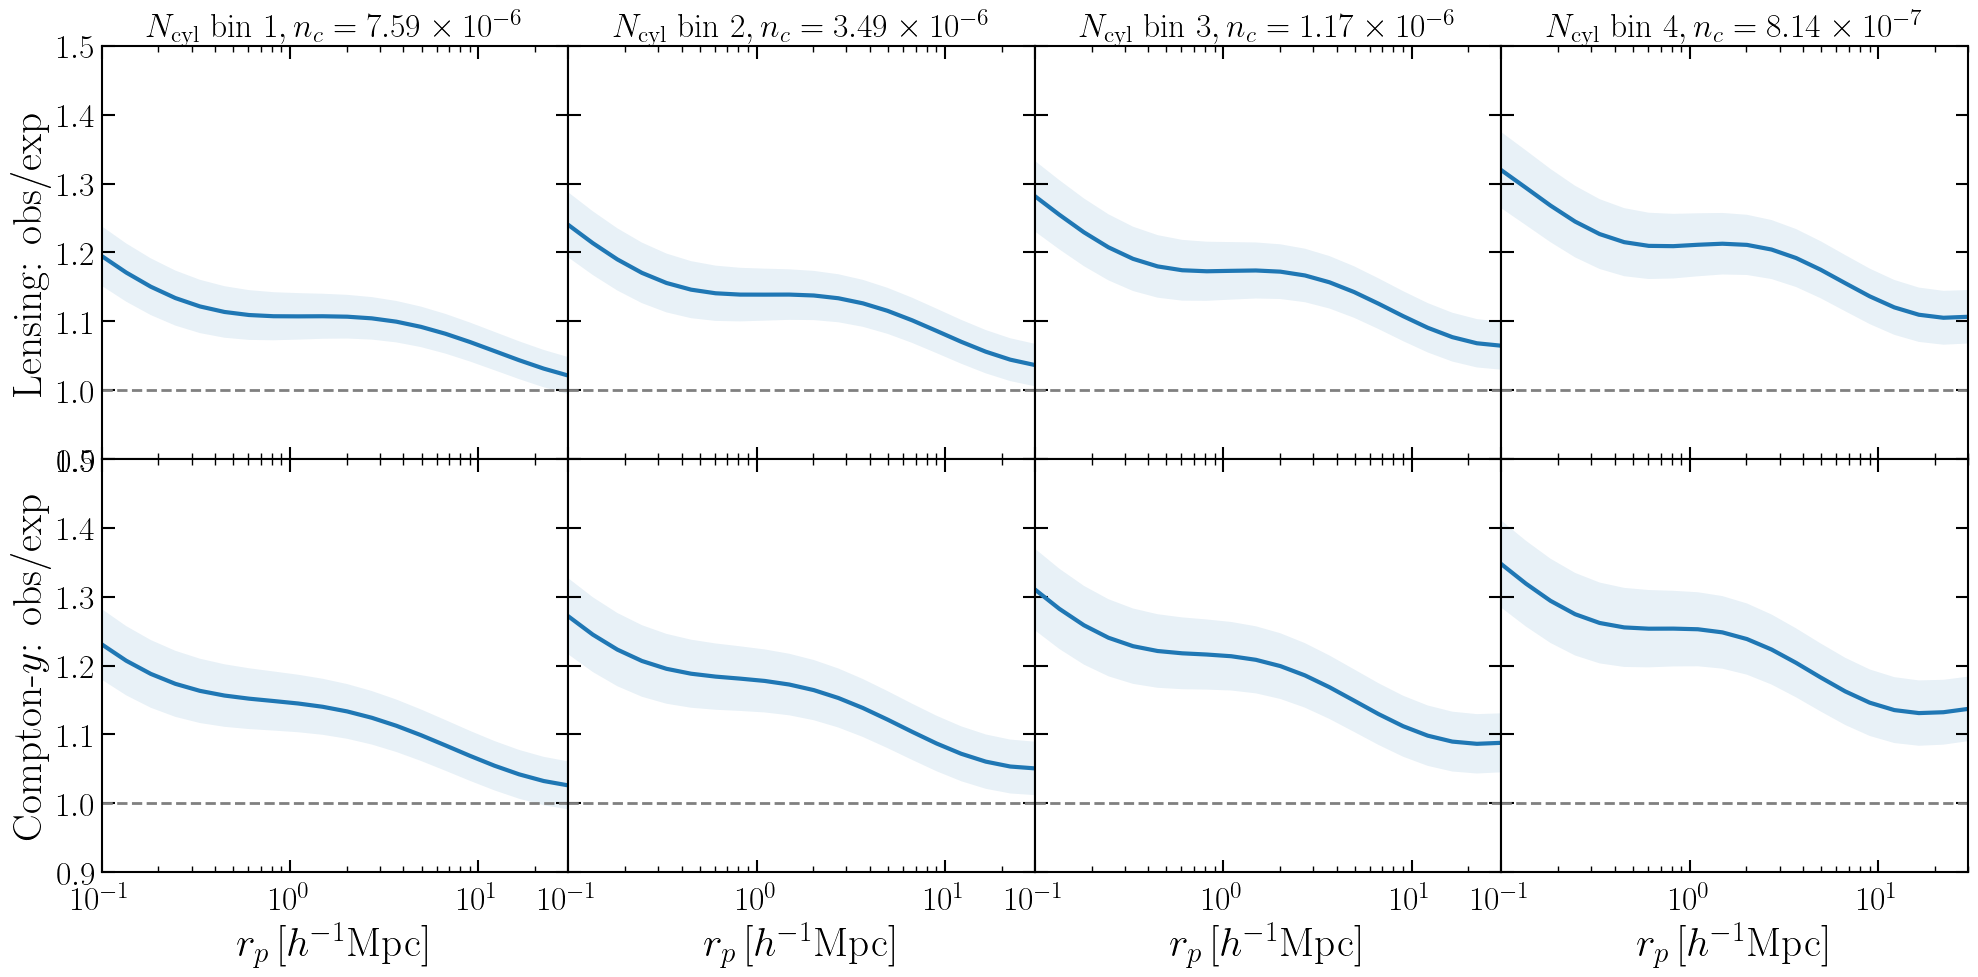

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Richness-selection bias summary, following the layout of
# code/richness_selection_plot_add_mc_weights.ipynb, but without the Sigma_g row.

# TODO: add real data
rp = np.geomspace(0.1, 30, 20)
num_clus_used = np.array([2396, 1103, 370, 257])
vol_flamingo = 681.0 ** 3

def latex_scientific(value, decimals=2):
    """Format a number as LaTeX scientific notation."""
    mantissa, exponent = f"{value:.{decimals}e}".split("e")
    return rf"${float(mantissa):.{decimals}f}\times10^{{{int(exponent)}}}$"

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 10),
    sharex=True,
    sharey="row",
    gridspec_kw={"wspace": 0, "hspace": 0},
)

col_titles = [rf"$N_{{\rm cyl}} {{\rm ~bin~{i}}}, n_c =\; $" for i in range(1, 5)]

row_ylabels = [
    r"Lensing: obs/exp",
    r"Compton-$y$: obs/exp",
]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title + latex_scientific(num_clus_used[col] / vol_flamingo))

for row, ylabel in enumerate(row_ylabels):
    axes[row, 0].set_ylabel(ylabel)

for col in range(4):
    axes[-1, col].set_xlabel(r"$r_p\,[h^{-1}{\rm Mpc}]$")

def placeholder_bias(rp, rich_col, row, offset=0.0):
    """TODO: replace with real obs/exp bias profiles."""
    amp = 0.12 + 0.035 * rich_col + 0.025 * row + offset
    slope = -0.28 + 0.04 * rich_col
    wiggle = 0.025 * np.sin(np.log(rp) * (1.2 + 0.15 * rich_col) + 0.6 * row)
    return 1.0 + amp * (rp / 0.3) ** slope + wiggle

def placeholder_err(rp, rich_col, row):
    """TODO: replace with real propagated uncertainty profiles."""
    return 0.025 + 0.008 * row + 0.004 * rich_col + 0.01 / np.sqrt(rp + 0.2)

for row in range(2):
    for col in range(4):
        ax = axes[row, col]

        offset = 0.03 if row == 0 else 0.04
        y_sim = placeholder_bias(rp, col, row, offset=offset)
        e_sim = placeholder_err(rp, col, row)
        line = ax.plot(rp, y_sim, lw=3)
        ax.fill_between(
            rp,
            y_sim - e_sim,
            y_sim + e_sim,
            interpolate=True,
            facecolor=line[0].get_c(),
            alpha=0.1,
        )

        ax.axhline(1, c="gray", ls="--")
        ax.set_ylim(0.9, 1.5)
        ax.set_xlim(0.1, 30)
        ax.set_xscale("log")
        ax.grid(False)
        ax.tick_params(which="major", length=9, width=1.5)
        ax.tick_params(which="minor", length=4, width=1.0)

        if col > 0:
            ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(left=0.07, right=0.99, bottom=0.08, top=0.92, wspace=0, hspace=0)

plt.show()

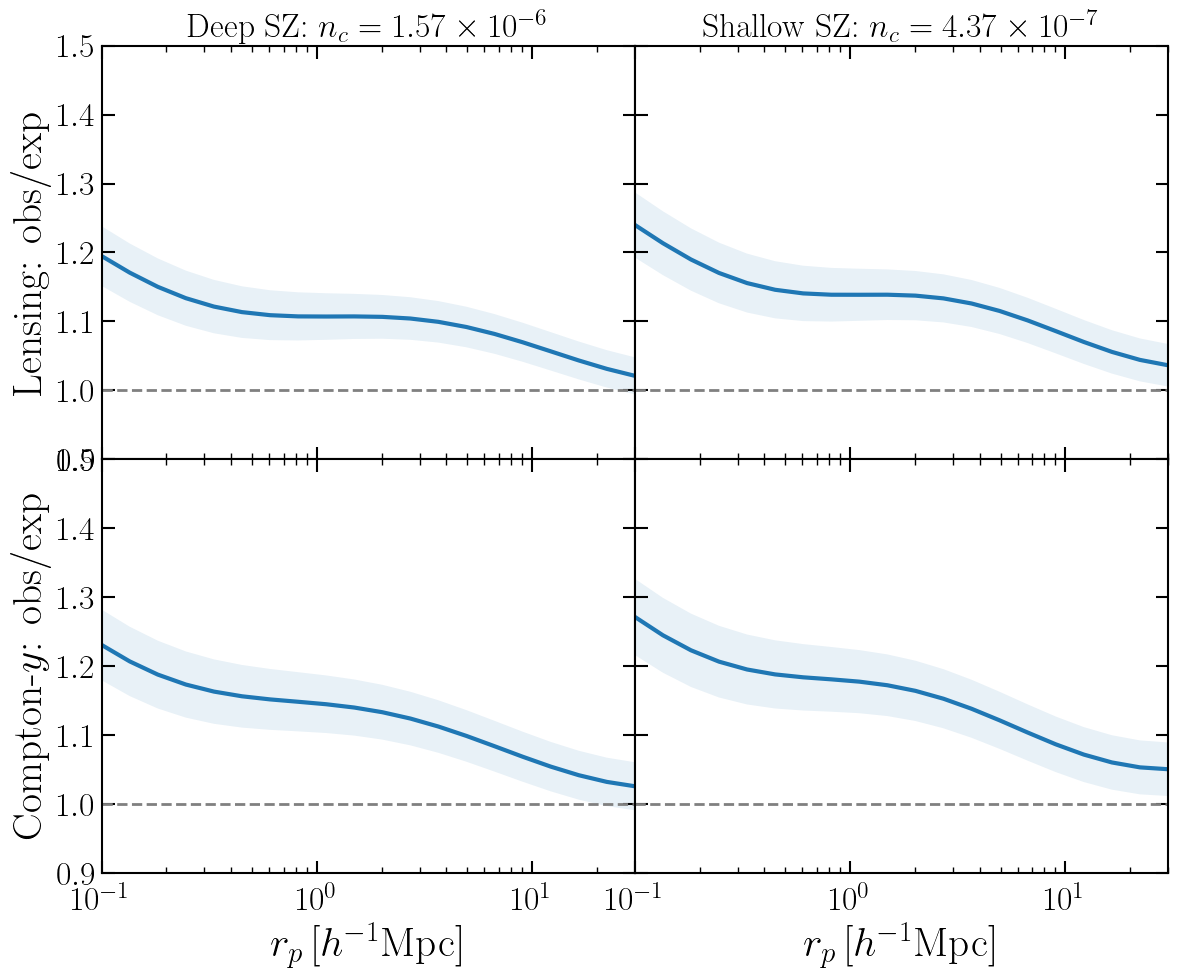

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Ycyl-selection bias summary, 2-column layout (deep/shallow SZ), no Sigma_g row.

# TODO: add real data
rp = np.geomspace(0.1, 30, 20)
num_clus_used = np.array([496, 138])  # SPTpol-500d (deep), SPT-SZ (shallow)
vol_flamingo = 681.0 ** 3

def latex_scientific(value, decimals=2):
    """Format a number as LaTeX scientific notation."""
    mantissa, exponent = f"{value:.{decimals}e}".split("e")
    return rf"${float(mantissa):.{decimals}f}\times10^{{{int(exponent)}}}$"

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 10),
    sharex=True,
    sharey="row",
    gridspec_kw={"wspace": 0, "hspace": 0},
)

col_titles = [
    r"Deep SZ: $n_c =\; $",
    r"Shallow SZ: $n_c =\; $",
]

row_ylabels = [
    r"Lensing: obs/exp",
    r"Compton-$y$: obs/exp",
]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title + latex_scientific(num_clus_used[col] / vol_flamingo))

for row, ylabel in enumerate(row_ylabels):
    axes[row, 0].set_ylabel(ylabel)

for col in range(2):
    axes[-1, col].set_xlabel(r"$r_p\,[h^{-1}{\rm Mpc}]$")

def placeholder_bias(rp, col, row, offset=0.0):
    """TODO: replace with real obs/exp bias profiles."""
    amp = 0.12 + 0.035 * col + 0.025 * row + offset
    slope = -0.28 + 0.04 * col
    wiggle = 0.025 * np.sin(np.log(rp) * (1.2 + 0.15 * col) + 0.6 * row)
    return 1.0 + amp * (rp / 0.3) ** slope + wiggle

def placeholder_err(rp, col, row):
    """TODO: replace with real propagated uncertainty profiles."""
    return 0.025 + 0.008 * row + 0.004 * col + 0.01 / np.sqrt(rp + 0.2)

for row in range(2):
    for col in range(2):
        ax = axes[row, col]

        offset = 0.03 if row == 0 else 0.04
        y_sim = placeholder_bias(rp, col, row, offset=offset)
        e_sim = placeholder_err(rp, col, row)
        line = ax.plot(rp, y_sim, lw=3)
        ax.fill_between(
            rp,
            y_sim - e_sim,
            y_sim + e_sim,
            interpolate=True,
            facecolor=line[0].get_c(),
            alpha=0.1,
        )

        ax.axhline(1, c="gray", ls="--")
        ax.set_ylim(0.9, 1.5)
        ax.set_xlim(0.1, 30)
        ax.set_xscale("log")
        ax.grid(False)
        ax.tick_params(which="major", length=9, width=1.5)
        ax.tick_params(which="minor", length=4, width=1.0)

        if col > 0:
            ax.tick_params(axis="y", which="both", labelleft=False)

fig.subplots_adjust(left=0.09, right=0.99, bottom=0.08, top=0.92, wspace=0, hspace=0)

plt.show()